In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yusuferenkaragz/iris-data/09-iris.csv


In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/kaggle/input/datasets/yusuferenkaragz/iris-data/09-iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
x=df.drop(columns=["Id","Species"]).values
y=df["Species"].values


<Axes: xlabel='SepalLengthCm'>

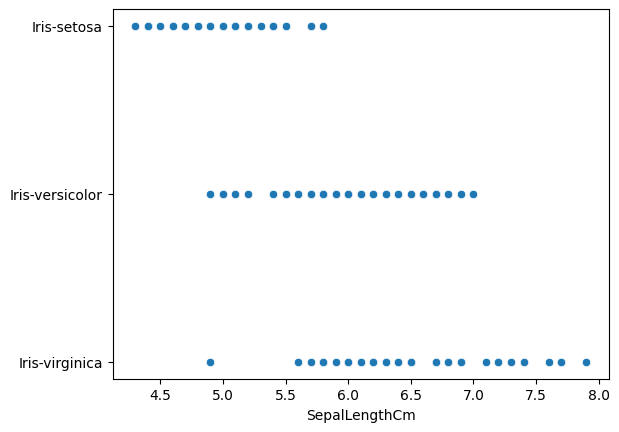

In [8]:
sns.scatterplot(x=df["SepalLengthCm"],y=y)

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le=LabelEncoder()

In [11]:
y=le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
x_test

array([[4.4, 3. , 1.3, 0.2],
       [6.1, 3. , 4.9, 1.8],
       [4.9, 2.4, 3.3, 1. ],
       [5. , 2.3, 3.3, 1. ],
       [4.4, 3.2, 1.3, 0.2],
       [6.3, 3.3, 4.7, 1.6],
       [4.6, 3.6, 1. , 0.2],
       [5.4, 3.4, 1.7, 0.2],
       [6.5, 3. , 5.2, 2. ],
       [5.4, 3. , 4.5, 1.5],
       [7.3, 2.9, 6.3, 1.8],
       [6.9, 3.1, 5.1, 2.3],
       [6.5, 3. , 5.8, 2.2],
       [6.4, 3.2, 4.5, 1.5],
       [5. , 3.4, 1.5, 0.2],
       [5. , 3.3, 1.4, 0.2],
       [5.8, 4. , 1.2, 0.2],
       [5.6, 2.5, 3.9, 1.1],
       [6.1, 2.9, 4.7, 1.4],
       [6. , 3. , 4.8, 1.8],
       [5.4, 3.7, 1.5, 0.2],
       [6.7, 3.1, 5.6, 2.4],
       [6.6, 2.9, 4.6, 1.3],
       [6.1, 2.6, 5.6, 1.4],
       [6.4, 2.8, 5.6, 2.2],
       [6.7, 3. , 5. , 1.7],
       [6.6, 3. , 4.4, 1.4],
       [5.7, 3.8, 1.7, 0.3],
       [6.5, 3. , 5.5, 1.8],
       [5.2, 3.4, 1.4, 0.2]])

In [14]:
x_train=torch.tensor(x_train,dtype=torch.float32)
x_test=torch.tensor(x_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)
y_test=torch.tensor(y_test,dtype=torch.long)

In [15]:
from torch import nn

In [16]:
class irisclassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_ls=nn.Sequential(
            nn.Linear(4,4),
            nn.ReLU(),
            nn.Linear(4,4),
            nn.ReLU(),
            nn.Linear(4,3)
        )
    def forward(self,x):
        return self.linear_ls(x)

In [17]:
model=irisclassifier()
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)



In [18]:
def calculate_accuracy(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc
    

In [19]:
y_logits=model(x_test)

In [20]:
y_pred_probs=torch.softmax(y_logits,dim=1).argmax(dim=1)

In [21]:
torch.argmax(y_pred_probs[0])

tensor(0)

In [22]:
epochs=200

train_losses=[]
test_losses=[]
train_acc=[]
test_accur=[]

for epoch in range(epochs):
    model.train()

    logit=model(x_train)
    loss=loss_fn(logit,y_train)
    pred=torch.softmax(logit,dim=1).argmax(dim=1)
    acc=calculate_accuracy(y_train,pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_acc.append(acc)

    model.eval()
    with torch.inference_mode():
        test_logit=model(x_test)

        test_loss=loss_fn(test_logit,y_test)
        test_pred=torch.softmax(test_logit,dim=1).argmax(dim=1)
        test_acc=calculate_accuracy(y_test,test_pred)
    test_losses.append(test_loss.item())
    test_accur.append(test_acc)

    if epoch % 20==0:
        print(f"epoch={epoch},loss={loss},accuracy={acc},test loss;{test_loss},test accuracy={test_acc}")

epoch=0,loss=1.1265147924423218,accuracy=33.33333333333333,test loss;1.1207821369171143,test accuracy=33.33333333333333
epoch=20,loss=0.9500238299369812,accuracy=65.83333333333333,test loss;0.9332006573677063,test accuracy=66.66666666666666
epoch=40,loss=0.5493982434272766,accuracy=69.16666666666667,test loss;0.5349752902984619,test accuracy=73.33333333333333
epoch=60,loss=0.33133286237716675,accuracy=97.5,test loss;0.32995226979255676,test accuracy=96.66666666666667
epoch=80,loss=0.19374755024909973,accuracy=97.5,test loss;0.2007022649049759,test accuracy=96.66666666666667
epoch=100,loss=0.11525212973356247,accuracy=97.5,test loss;0.12783566117286682,test accuracy=96.66666666666667
epoch=120,loss=0.08293404430150986,accuracy=98.33333333333333,test loss;0.09595632553100586,test accuracy=96.66666666666667
epoch=140,loss=0.06902483850717545,accuracy=98.33333333333333,test loss;0.08011458069086075,test accuracy=100.0
epoch=160,loss=0.0619376078248024,accuracy=98.33333333333333,test loss;0

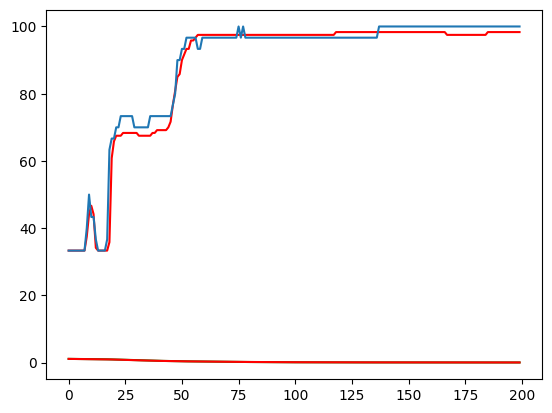

In [23]:
plt.plot(train_losses,label="train losses",color="g")
plt.plot(test_losses,label="test losses",color="r")
plt.plot(train_acc,label="train accuracy",color="r")
plt.plot(test_accur,label="test accuracy")

In [24]:
!pip install torchmetrics

In [25]:
from torchmetrics.classification import MulticlassAccuracy

In [26]:
accuracy=MulticlassAccuracy(num_classes=3)

In [27]:
#torchMetrics kütüphanesi kullanarak alternatif yol
epochs=200
model2=irisclassifier()
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model2.parameters(),lr=0.01)

for epoch in range(epochs):
    model2.train()
    logit=model2(x_train)
    loss=loss_fn(logit,y_train)

    pred=torch.softmax(logit,dim=1).argmax(dim=1)
    acc=accuracy(pred,y_train).item()*100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model2.eval()
    with torch.inference_mode():
        test_logit=model2(x_test)
        test_loss=loss_fn(test_logit,y_test)

        test_pred=torch.softmax(test_logit,dim=1).argmax(dim=1)
        test_acc=accuracy(test_pred,y_test)
    if epoch % 20==0:
        print(f"epoch={epoch},loss={loss},accuracy={acc},test loss;{test_loss},test accuracy={test_acc}")

epoch=0,loss=1.148410677909851,accuracy=0.0,test loss;1.128062129020691,test accuracy=0.0
epoch=20,loss=1.012075662612915,accuracy=33.33333432674408,test loss;1.0074803829193115,test accuracy=0.3333333432674408
epoch=40,loss=0.7771607041358948,accuracy=69.16667222976685,test loss;0.7690314650535583,test accuracy=0.7333333492279053
epoch=60,loss=0.5665681958198547,accuracy=87.5,test loss;0.5624492764472961,test accuracy=0.8999999761581421
epoch=80,loss=0.37547484040260315,accuracy=95.00000476837158,test loss;0.37680044770240784,test accuracy=0.9666666984558105
epoch=100,loss=0.22111937403678894,accuracy=97.50000238418579,test loss;0.22887340188026428,test accuracy=0.9666666984558105
epoch=120,loss=0.13155178725719452,accuracy=97.50000238418579,test loss;0.14456917345523834,test accuracy=1.0
epoch=140,loss=0.0896366760134697,accuracy=98.33333492279053,test loss;0.1032179519534111,test accuracy=1.0
epoch=160,loss=0.07118033617734909,accuracy=98.33333492279053,test loss;0.08196558803319931

In [28]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [29]:
cm=MulticlassConfusionMatrix(num_classes=3)

In [30]:
matrix=cm(test_pred,y_test)

In [31]:
print(matrix)

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])


In [32]:
from torchmetrics.utilities.plot import plot_confusion_matrix

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

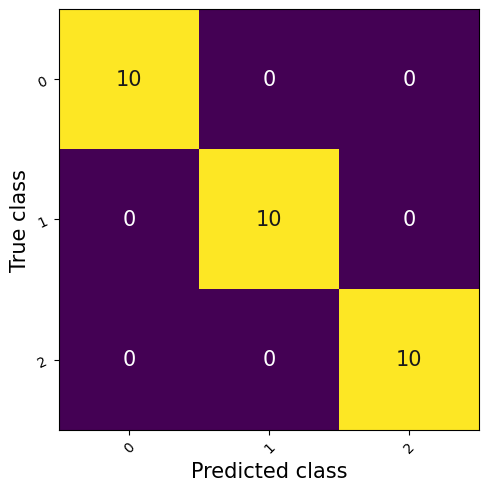

In [33]:
plot_confusion_matrix(matrix)